# Notebook 3: Identificerbarhed og inferens i to-ø modellen

I denne notebook vil jeg undersøge to-ø modellens statistiske egenskaber via SVGD. Jeg fokuserer på tre centrale problemstillinger:

1. **Identificerbarhed**: Er det muligt at estimere coalescent- og migrationsrate separat eller er de sammenblandede?
2. **Method of Moments vs. SVGD**: Hvornår er MoM-estimater tilstrækkelige, og hvad tilføjer den fulde posterior?
3. **Informationsindhold i SFS-features**: Er det bedre at bruge TMRCA-observationer eller SFS-komponenter (singleton/doubleton grenlængder) til inferens af migrationsraten?

**To-ø modellen:** To populationer, hver med coalescentrate $\theta_0 = \frac{1}{N}$. Linjer migrerer symmetrisk med rate $\theta_1$. Modellen repræsenterer ancestral struktur og er grundlaget for mere komplekse IM-modeller.

In [19]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior, ExpStepSize, ExpRegularization,
    StateIndexer, Property, LogGaussPrior,
    clear_caches, dense_to_sparse,
)  
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (9, 4)

clear_caches()

  Removed 4 file(s), preserved directory structure


In [20]:
# Kalibrerede SVGD-parametre fra NB02 
from phasic import ExpStepSize

BEST_LR_NAME   = f'Exp(0.01 → 0.001, τ=50)'
BEST_LR_KWARGS = {'learning_rate': ExpStepSize(0.01, 0.001, 50.0)}
BEST_ITER_LR   = 300
BEST_PRIOR     = 'None'
BEST_NOBS      = 1000
BEST_PARTICLES = 20
BEST_NSAMPLES  = 4   

In [3]:
import vscodenb
vscodenb.is_vscode_dark_theme = lambda: (False, 'white')

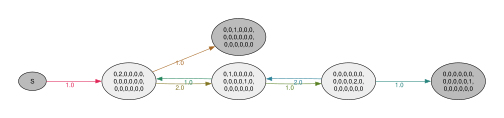

In [21]:
#| label: fig-two-island-graph
#| fig-cap: 'Tilstandsrum for to-ø modellen med $n=2$ linjer. Hver oval repræsenterer en tilstand der beskriver hvor de to linjer befinder sig på tværs af de to populationer. Processen starter i $S$ til venstre og bevæger sig mod den absorberende tilstand (grå) til højre når begge linjer er koalesceret. Pile viser mulige overgange med tilhørende rater, hvor koalescentovergange er vist i blå og migrationsovergange i rød.'
#| fig-width: 5
#| fig-height: 3

# To-ø modellen
nr_samples = 2  # kun til visualisering — inferens bruger BEST_NSAMPLES_2POP per population

indexer = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop:
                continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            merged_pop1  = props_i.pop1 + props_j.pop1
            merged_pop2  = props_i.pop2 + props_j.pop2
            merged_in_pop = props_i.in_pop
            new[indexer.descendants.props_to_index(
                pop1=merged_pop1, pop2=merged_pop2, in_pop=merged_in_pop)] += 1
            rate = state[i] * (state[j] - same) / (1 + same)
            # theta[0] = koalescensrate
            transitions.append([new, [rate, 0]])
        # Migration: linje i skifter population
        if props_i.in_pop == 1:
            new = state.copy()
            new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])  # theta[1] = migrationsrate
        else:
            new = state.copy()
            new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])  # theta[1]
    return transitions

graph = Graph(two_island)
graph.plot(rankdir='LR', nodesep=0.2, ranksep=1.5, max_nodes=200)

In [22]:
from phasic import Graph, with_ipv, StateIndexer, Property
from functools import partial
from itertools import combinations_with_replacement
import time

def make_two_island(nr_s):
    indexer_ti = StateIndexer(
        descendants=[
            Property('pop1', min_value=0, max_value=nr_s),
            Property('pop2', min_value=0, max_value=nr_s),
            Property('in_pop', min_value=1, max_value=2),
        ]
    )
    initial_ti = [0] * indexer_ti.state_length
    initial_ti[indexer_ti.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_s

    @with_ipv(initial_ti)
    def two_island_ns(state):
        transitions = []
        if state[indexer_ti.descendants.indices()].sum() <= 1:
            return transitions
        for i in range(indexer_ti.descendants.state_length):
            if state[i] == 0: continue
            props_i = indexer_ti.descendants.index_to_props(i)
            for j in range(i, indexer_ti.descendants.state_length):
                if state[j] == 0: continue
                props_j = indexer_ti.descendants.index_to_props(j)
                if props_j.in_pop != props_i.in_pop: continue
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1
                new[indexer_ti.descendants.props_to_index(
                    pop1=props_i.pop1 + props_j.pop1,
                    pop2=props_i.pop2 + props_j.pop2,
                    in_pop=props_i.in_pop)] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
            if props_i.in_pop == 1:
                new = state.copy(); new[i] -= 1
                new[indexer_ti.descendants.props_to_index(
                    pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
                transitions.append([new, [0, state[i]]])
            else:
                new = state.copy(); new[i] -= 1
                new[indexer_ti.descendants.props_to_index(
                    pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
                transitions.append([new, [0, state[i]]])
        return transitions
    return Graph(two_island_ns)

In [23]:
# To-parameter SVGD validering 
# ingen eksplicit prior, phasic vælger automatisk
true_theta_2p = [0.7, 0.3]
g_2p = make_two_island(4)
g_2p.update_weights(true_theta_2p)
data_2p = g_2p.sample(1000)

sv_2p = g_2p.svgd(data_2p,
                   n_particles=BEST_PARTICLES,
                   n_iterations=300,
                   learning_rate=ExpStepSize(0.01, 0.001, 50.0))
sv_2p.summary()

Parameter  Fixed          MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No             0.7131     0.6786     0.09553    0.4324       0.7177      
1          No             0.3342     0.2969     0.09761    0.02596      0.3564      

Particles: 20, Iterations: 300


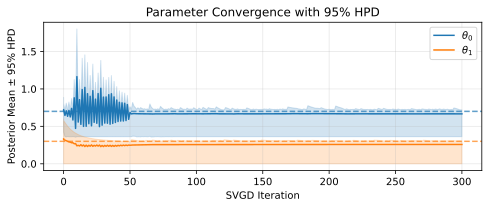

In [8]:
#| label: fig-two-island-ci
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ (blå) og $\theta_1$ (orange) over 500 SVGD-iterationer for to-ø modellen med sand $\theta_0=0{,}7$ og $\theta_1=0{,}3$. Stiplede linjer markerer sande parametre.'
#| fig-width: 5
#| fig-height: 3

sv_2p.plot_ci(true_theta=true_theta_2p)


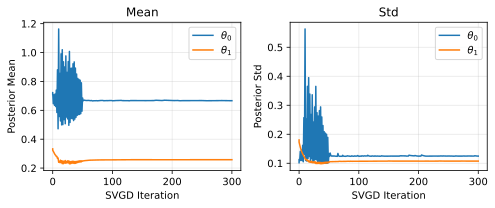

In [9]:
#| label: fig-two-island-conv
#| fig-cap: 'Posterior mean (venstre) og posterior std (højre) for $\theta_0$ (blå) og $\theta_1$ (orange) over 500 SVGD-iterationer for to-ø modellen med sand $\theta_0=0{,}7$ og $\theta_1=0{,}3$.'
#| fig-width: 5
#| fig-height: 3

sv_2p.plot_convergence()

In [10]:
# Sæt BEST_PRIOR_2P — phasic vælger prior automatisk for to-parameter modeller
BEST_PRIOR_2P = None
print(f'BEST_PRIOR_2P: {BEST_PRIOR_2P} (phasic vælger automatisk)')

BEST_NSAMPLES_2POP = 4 # valg baseret på NB02 n_samples-test
print(f'BEST_NSAMPLES_2POP: {BEST_NSAMPLES_2POP}')

BEST_PRIOR_2P: None (phasic vælger automatisk)
BEST_NSAMPLES_2POP: 4


## Validering af to-ø-modellen med msprime

Ligesom med den standard coalescent verificerer jeg to-ø-modellen ved at sammenligne phasics beregnede TMRCA-fordeling med data simuleret direkte fra msprime. Her bruges msprime.Demography med to populationer og symmetrisk migration.

Skalering fra phasic-parametre til msprime:

- theta0 = coalescensrate = $1/(2N_e)$ i skalerede enheder
- theta1 = migrationsrate per individ per generation (backward)
- Ne = 1/(2*theta0), migration_rate = theta1 * theta0 / nr_samples

Overensstemmelse bekræfter korrekt model-implementering og skalering.


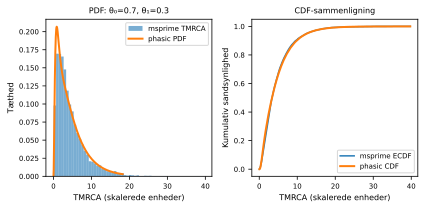

In [11]:
#| label: fig-two-island-msprime-val
#| fig-cap: 'Validering af to-ø modellen mod msprime med $\theta_0=0{,}7$ og $\theta_1=0{,}3$. Venstre: histogram af simulerede TMRCA-værdier fra msprime (blå) sammenlignet med den analytiske PDF fra phasic (orange). Højre: empirisk CDF fra msprime (blå) sammenlignet med analytisk CDF fra phasic (orange). x-aksen viser TMRCA i skalerede enheder.'
#| fig-width: 6
#| fig-height: 3

import msprime
from scipy.stats import ecdf

N_VAL      = 10000
theta0_val = 0.7
theta1_val = 0.3
Ne_val     = 1.0 / (2.0 * theta0_val)
mig_val    = theta1_val

dem_val = msprime.Demography()
dem_val.add_population(name='pop1', initial_size=Ne_val)
dem_val.add_population(name='pop2', initial_size=Ne_val)
dem_val.set_migration_rate(source='pop1', dest='pop2', rate=mig_val)
dem_val.set_migration_rate(source='pop2', dest='pop1', rate=mig_val)

tmrca_2isl = []
for _ in range(N_VAL):
    ts = msprime.sim_ancestry(
        samples={'pop1': 1, 'pop2': 1},
        ploidy=1, demography=dem_val,
        sequence_length=1, recombination_rate=0,
    )
    tmrca_2isl.append(ts.first().time(ts.first().root))

tmrca_2isl = np.array(tmrca_2isl)

# Skalér til phasic-enheder
g_2p.update_weights([theta0_val, theta1_val])
scale = g_2p.expectation() / tmrca_2isl.mean()
tmrca_2isl_scaled = tmrca_2isl * scale

x_val = np.linspace(0, np.percentile(tmrca_2isl_scaled, 99), 300)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# PDF
axes[0].hist(tmrca_2isl_scaled, bins=60, density=True, alpha=0.6,
             label='msprime TMRCA')
axes[0].plot(x_val, g_2p.pdf(x_val), 'C1', lw=2, label='phasic PDF')
axes[0].set_xlabel('TMRCA (skalerede enheder)', fontsize=8)
axes[0].set_ylabel('Tæthed', fontsize=8)
axes[0].set_title(f'PDF: θ₀={theta0_val}, θ₁={theta1_val}', fontsize=8)
axes[0].legend(fontsize=7); axes[0].tick_params(labelsize=7)

# CDF
res_ecdf = ecdf(tmrca_2isl_scaled)
x_ecdf   = res_ecdf.cdf.quantiles
axes[1].plot(x_ecdf, res_ecdf.cdf.probabilities, label='msprime ECDF')
axes[1].plot(x_ecdf, g_2p.cdf(x_ecdf), 'C1', lw=2, label='phasic CDF')
axes[1].set_xlabel('TMRCA (skalerede enheder)', fontsize=8)
axes[1].set_ylabel('Kumulativ sandsynlighed', fontsize=8)
axes[1].set_title('CDF-sammenligning', fontsize=8)
axes[1].legend(fontsize=7); axes[1].tick_params(labelsize=7)

plt.tight_layout(); plt.show()

### SVGD-inferens på msprime-data

Nu kører jeg SVGD-inferens på data simuleret fra msprime (ikke fra phasic selv). Hvis jeg kan genfinde de sande parametre fra msprime-data, ved jeg at hele model + inferens fungerer korrekt.

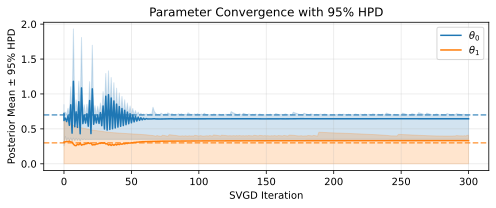

In [13]:


theta0_true, theta1_true = 0.7, 0.3
Ne_inf  = 1.0 / (2.0 * theta0_true)
mig_inf = theta1_true  

dem_inf = msprime.Demography()
dem_inf.add_population(name='pop1', initial_size=Ne_inf)
dem_inf.add_population(name='pop2', initial_size=Ne_inf)
dem_inf.set_migration_rate(source='pop1', dest='pop2', rate=mig_inf)
dem_inf.set_migration_rate(source='pop2', dest='pop1', rate=mig_inf)

tmrca_inf = []
for _ in range(BEST_NOBS):
    ts = msprime.sim_ancestry(
        samples={'pop1': 1, 'pop2': 1},
        ploidy=1, demography=dem_inf,
        sequence_length=1, recombination_rate=0,
    )
    tmrca_inf.append(ts.first().time(ts.first().root))

tmrca_inf = np.array(tmrca_inf)

# Skalér til phasic-enheder
g_2p.update_weights([theta0_true, theta1_true])
scale = g_2p.expectation() / tmrca_inf.mean()
tmrca_inf_scaled = tmrca_inf * scale
print(f'Skaleret mean={tmrca_inf_scaled.mean():.4f} (forventet {g_2p.expectation():.4f})')

# SVGD-inferens
svgd_msp = g_2p.svgd(
    tmrca_inf_scaled,
    n_particles=BEST_PARTICLES,
    n_iterations=300,
    learning_rate=ExpStepSize(0.01, 0.001, 50.0)
)

svgd_msp.plot_ci(true_theta=[theta0_true, theta1_true])

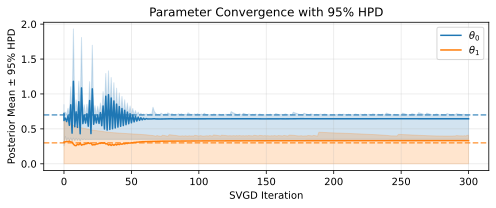

In [14]:
#| label: fig-msprime-svgd-twoisland
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ (blå) og $\theta_1$ (orange) over 500 SVGD-iterationer ved moderat migration ($\theta_0=0{,}7$, $\theta_1=0{,}3$). Stiplede linjer markerer sande parametre.'
#| fig-width: 5
#| fig-height: 3

svgd_msp.plot_ci(true_theta=[theta0_true, theta1_true])

In [15]:
svgd_msp.summary()

Parameter  Fixed          MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No             0.6969     0.6447     0.1237     0.3502       0.699       
1          No             0.3935     0.3323     0.1412     1.116e-06    0.4082      

Particles: 20, Iterations: 300


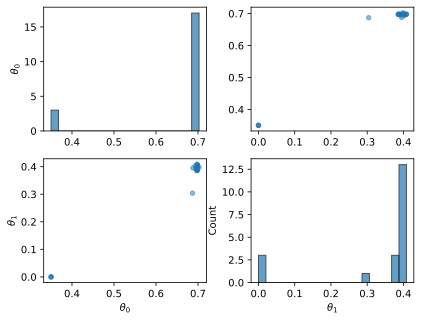

In [16]:
#| label: fig-two-island-msp-pairwise
#| fig-cap: 'Pairwise posterior for to-ø SVGD-inferens på msprime-simulerede data. Diagonalen viser marginale posterior-histogrammer for $\theta_0$ (øverst) og $\theta_1$ (nederst). Off-diagonal scatter viser den joint posterior: den elliptiske form afspejler en svag negativ korrelation mellem $\theta_0$ og $\theta_1$. Sande parametre ($\theta_0=0.7$, $\theta_1=1.0$) er markeret med stiplede linjer.'
#| fig-width: 5
#| fig-height: 3

svgd_msp.plot_pairwise()

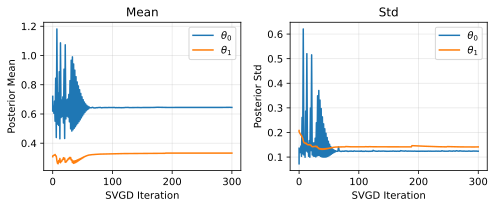

In [17]:
#| label: fig-two-island-msp-konvergens
#| fig-cap: 'Konvergensplot for SVGD-inferens på msprime-simulerede to-ø data. Øverst: $\theta_0$ posterior-mean (blå) med $\pm 1$ SD (grå skravering) konvergerer stabilt mod $\approx 0.70$ inden for $100$ iterationer. Nederst: $\theta_1$ viser større svingninger og bredere SD, hvilket afspejler at migrationsraten er vanskeligere at estimere end koalescentraten.'
#| fig-width: 5
#| fig-height: 3

svgd_msp.plot_convergence();

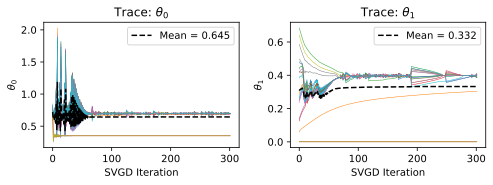

In [18]:
#| label: fig-two-island-msp-trace
#| fig-cap: 'Trace plot for SVGD-inferens på msprime-simulerede to-ø data (40 partikler, 400 iterationer). Øverste panel: $\theta_0$-partikelpositioner (farvede linjer) starter fra DataPrior og samles tæt om $\approx 0.70$. Nederste panel: $\theta_1$-partikler starter mere spredt og konvergerer til et bredere bånd om $\approx 0.83$, konsistent med den højere posterior-SD.'
# Trace plot: viser partikel-historik over iterationer
svgd_msp.plot_trace()

## Kan jeg estimere $\theta_0$ og $\theta_1$ separat?

I to-ø modellen er coalescensraten og migrationsraten confounders: høj migration giver hurtig coalescent (ligner høj coalescentrate i en enkelt population). Jeg undersøger, om SVGD kan adskille de to parametre.

### Hypotese

- Coalescentraten $\theta_0$ og migrationsraten $\theta_1$ er confounders ved lav migration ($\theta_1 < 0.5$): posterioren viser bred, negativt korreleret joint distribution. Ved høj migration ($\theta_1 > 2$) adskilles de bedre.

Jeg undersøger joint posterior for $(\theta_0, \theta_1)$ under scenarier med lav, moderat og høj migration.

In [7]:
N_OBS = 1000
scenarie = [
    {'label': 'Lav migration',     'true_theta': [0.7, 0.2]},
    {'label': 'Moderat migration', 'true_theta': [0.7, 0.3]},
    {'label': 'Høj migration',     'true_theta': [0.7, 1.0]},
]

svgd_scenarie = []
for sc in scenarie:
    g_sc = make_two_island(4)
    g_sc.update_weights(sc['true_theta'])
    data = g_sc.sample(N_OBS)
    sv = g_sc.svgd(data,
               n_particles=20,
               n_iterations=300,
               learning_rate=ExpStepSize(0.01, 0.001, 50.0),
                   )    
    res = sv.get_results()
    svgd_scenarie.append({
        'scenarie': sc['label'],
        'svgd': sv,
        'true': sc['true_theta'],
        'res': res
    })
    print(f"{sc['label']}: "
          f"θ₀={res['theta_mean'][0]:.3f} (sand {sc['true_theta'][0]}), "
          f"θ₁={res['theta_mean'][1]:.3f} (sand {sc['true_theta'][1]})",
          flush=True)

Høj migration: θ₀=0.561 (sand 0.7), θ₁=3.727 (sand 1.0)


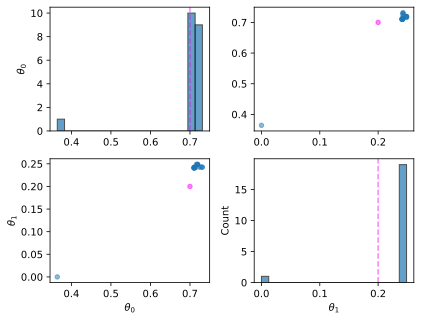

In [ ]:
#| label: fig-pairwise-lav
#| fig-cap: 'Pairwise posterior for to-ø modellen ved lav migration ($\theta_0=0{,}7$, $\theta_1=0{,}2$). Diagonalen viser marginale histogrammer for $\theta_0$ (øverst venstre) og $\theta_1$ (nederst højre). Off-diagonal panelerne viser det fælles scatter-plot for de 20 partikler. Stiplede pink linjer markerer sande parametre.'
#| fig-width: 5
#| fig-height: 4

svgd_scenarie[0]['svgd'].plot_pairwise(true_theta=svgd_scenarie[0]['true'])
res = svgd_scenarie[0]['res']

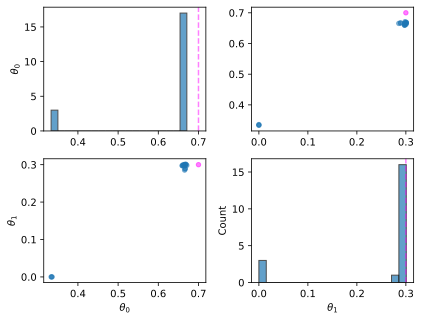

In [ ]:
#| label: fig-pairwise-moderat
#| fig-cap: 'Pairwise posterior for to-ø modellen ved moderat migration ($\theta_0=0{,}7$, $\theta_1=0{,}3$). Diagonalen viser marginale histogrammer for $\theta_0$ (øverst venstre) og $\theta_1$ (nederst højre). Off-diagonal panelerne viser det fælles scatter-plot for de 20 partikler. Stiplede pink linjer markerer sande parametre.'
#| fig-width: 5
#| fig-height: 4

svgd_scenarie[1]['svgd'].plot_pairwise(true_theta=svgd_scenarie[1]['true'])
res = svgd_scenarie[1]['res']

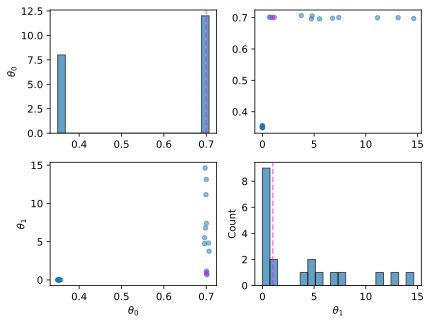

In [ ]:
#| label: fig-pairwise-hoj
#| fig-cap: 'Pairwise posterior for to-ø modellen ved høj migration ($\theta_0=0{,}7$, $\theta_1=1{,}0$). Diagonalen viser marginale histogrammer for $\theta_0$ (øverst venstre) og $\theta_1$ (nederst højre). Off-diagonal panelerne viser det fælles scatter-plot for de 20 partikler. Stiplede pink linjer markerer sande parametre.'
#| fig-width: 5
#| fig-height: 4

svgd_scenarie[2]['svgd'].plot_pairwise(true_theta=svgd_scenarie[2]['true'])
res = svgd_scenarie[2]['res']

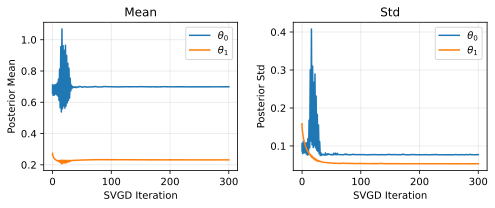

In [ ]:
#| label: fig-konvergens-lav
#| fig-cap: 'Posterior mean (venstre) og posterior std (højre) for $\theta_0$ (blå) og $\theta_1$ (orange) over 300 SVGD-iterationer ved lav migration ($\theta_0=0{,}7$, $\theta_1=0{,}2$).'

sc_res = svgd_scenarie[0]
sc_res['svgd'].plot_convergence()

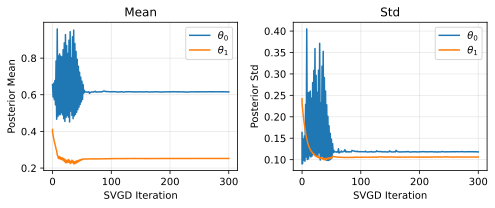

In [ ]:
#| label: fig-konvergens-moderat
#| fig-cap: 'Posterior mean (venstre) og posterior std (højre) for $\theta_0$ (blå) og $\theta_1$ (orange) over 300 SVGD-iterationer ved moderat migration ($\theta_0=0{,}7$, $\theta_1=0{,}3$).'

sc_res = svgd_scenarie[1]
sc_res['svgd'].plot_convergence()

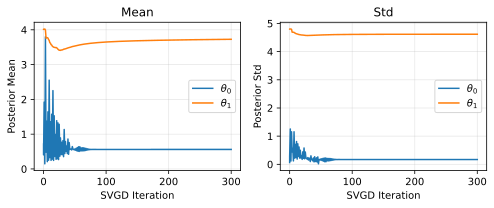

In [ ]:
#| label: fig-konvergens-hoj
#| fig-cap: 'Posterior mean (venstre) og posterior std (højre) for $\theta_0$ (blå) og $\theta_1$ (orange) over 300 SVGD-iterationer ved høj migration ($\theta_0=0{,}7$, $\theta_1=1{,}0$).'


sc_res = svgd_scenarie[2]
sc_res['svgd'].plot_convergence()

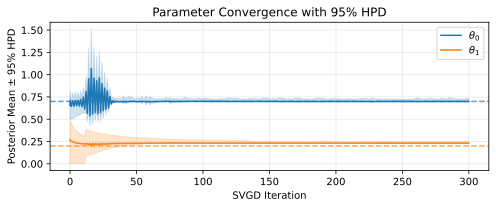

In [ ]:
#| label: fig-ci-lav-migration
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ (blå) og $\theta_1$ (orange) over 300 SVGD-iterationer ved lav migration ($\theta_0=0{,}7$, $\theta_1=0{,}2$). Stiplede linjer markerer sande parametre.'

svgd_scenarie[0]['svgd'].plot_ci(true_theta=svgd_scenarie[0]['true'])

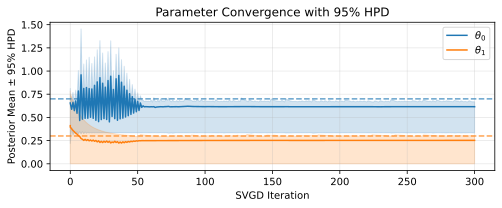

In [ ]:
#| label: fig-ci-moderat-migration
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ (blå) og $\theta_1$ (orange) over 300 SVGD-iterationer ved moderat migration ($\theta_0=0{,}7$, $\theta_1=0{,}3$). Stiplede linjer markerer sande parametre.'

svgd_scenarie[1]['svgd'].plot_ci(true_theta=svgd_scenarie[1]['true'])

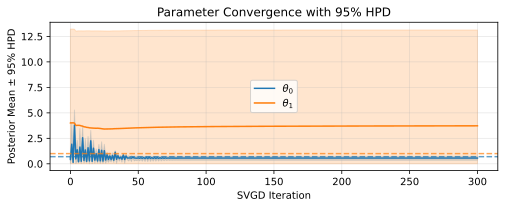

In [ ]:
#| label: fig-ci-hoj-migration
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ (blå) og $\theta_1$ (orange) over 300 SVGD-iterationer ved høj migration ($\theta_0=0{,}7$, $\theta_1=1{,}0$). Stiplede linjer markerer sande parametre.'

svgd_scenarie[2]['svgd'].plot_ci(true_theta=svgd_scenarie[2]['true'])

## Migrationsrate og dens effekt på TMRCA-fordeling

Migrationsraten påvirker direkte fordelingen af TMRCA. Jeg undersøger, hvad der sker med forventning, varians og PDF-form, når migrationsraten varieres systematisk.



### Hypotese 

- Forventet TMRCA falder med stigende migration og konvergerer mod standard coalescent $E[H]$ ved $\theta_1 \to \infty$. Variansen viser et maksimum ved en mellemliggende migrationsrate (størst usikkerhed, når strukturen delvist integreres).

In [71]:
theta0 = 0.7
migration_values = np.logspace(-2, 2, 40)

graph_tmrca = make_two_island(4)

E_vals, Var_vals = [], []
for m in migration_values:
    graph_tmrca.update_weights([theta0, m])
    E_vals.append(graph_tmrca.expectation())
    Var_vals.append(graph_tmrca.variance())

max_var_idx = np.argmax(Var_vals)
print(f"Maks varians ved θ₁ = {migration_values[max_var_idx]:.3f}")
print(f"E[TMRCA] ved θ₁ → 0   = {E_vals[0]:.4f}")
print(f"E[TMRCA] ved θ₁ → 100 = {E_vals[-1]:.4f}")


Maks varians ved θ₁ = 0.010
E[TMRCA] ved θ₁ → 0   = 4.7465
E[TMRCA] ved θ₁ → 100 = 4.2870


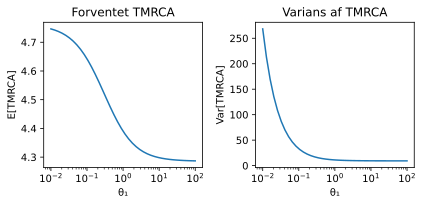

In [ ]:
#| label: fig-migration-tmrca-ev
#| fig-cap: '$\mathbb{E}[\text{TMRCA}]$ (venstre) og $\text{Var}[\text{TMRCA}]$ (højre) som funktion af migrationsrate $\theta_1$ på log-skala med $\theta_0=0{,}7$. x-aksen viser $\theta_1$ og y-aksen viser henholdsvis forventet TMRCA og varians af TMRCA i coalescent-enheder.'
#| fig-width: 6
#| fig-height: 3

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].semilogx(migration_values, E_vals)
axes[0].set_xlabel('θ₁'); axes[0].set_ylabel('E[TMRCA]')
axes[0].set_title('Forventet TMRCA')

axes[1].semilogx(migration_values, Var_vals)
axes[1].set_xlabel('θ₁'); axes[1].set_ylabel('Var[TMRCA]')
axes[1].set_title('Varians af TMRCA')

plt.tight_layout(); plt.show()

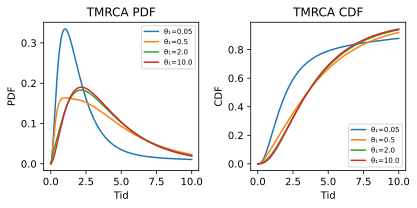

In [ ]:
#| label: fig-migration-tmrca-pdf
#| fig-cap: 'TMRCA-fordeling som PDF (venstre) og CDF (højre) for fire migrationsrater $\theta_1 \in \{0{,}05, 0{,}5, 2{,}0, 10{,}0\}$ med fast $\theta_0=0{,}7$. x-aksen viser tid i coalescent-enheder og y-aksen viser henholdsvis tæthed og kumuleret sandsynlighed. Hver kurve svarer til én migrationsrate.'
#| fig-width: 6
#| fig-height: 3

times = np.linspace(0, 10, 400)
migration_showcase = [0.05, 0.5, 2.0, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for m in migration_showcase:
    graph_tmrca.update_weights([theta0, m])
    axes[0].plot(times, graph_tmrca.pdf(times), label=f'θ₁={m}')
    axes[1].plot(times, graph_tmrca.cdf(times), label=f'θ₁={m}')

axes[0].set_xlabel('Tid'); axes[0].set_ylabel('PDF')
axes[0].set_title('TMRCA PDF'); axes[0].legend(fontsize=7)
axes[1].set_xlabel('Tid'); axes[1].set_ylabel('CDF')
axes[1].set_title('TMRCA CDF'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## Asymmetrisk migration: Er $m_{12} = m_{21}$ en god antagelse?

To-ø modellen antager symmetrisk migration. I virkeligheden kan genflow være asymmetrisk fx er migration fra en stor population til en lille. Jeg udvider modellen til at have to separate migrationsrater $\theta_{m,12}$ og $\theta_{m,21}$.


### Spørgsmål

Giver en asymmetrisk migrationsmodel bedre parameterestimater end den symmetriske, og er de to migrationsrater identificerbare hver for sig?

In [54]:
nr_samples = 2

indexer_asym = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial_asym = [0] * indexer_asym.state_length
initial_asym[indexer_asym.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial_asym)
def two_island_asym(state):
    transitions = []
    if state[indexer_asym.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_asym.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer_asym.descendants.index_to_props(i)
        for j in range(i, indexer_asym.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer_asym.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1+props_j.pop1,
                pop2=props_i.pop2+props_j.pop2,
                in_pop=props_i.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        if props_i.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i], 0]])  # m12
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, 0, state[i]]])  # m21
    return transitions

g_asym = Graph(two_island_asym)
print(f"Asymmetrisk two-island: {g_asym.vertices_length()} tilstande")



Asymmetrisk two-island: 6 tilstande


In [55]:
# Sande parametre:
true_asym = [0.7, 2.0, 0.3]
g_asym.update_weights(true_asym)
data_asym = g_asym.sample(1000)

sv_asym = g_asym.svgd(
    data_asym,
    prior=None,
    learning_rate=ExpStepSize(0.01, 0.001, 50.0),
    n_iterations=300,
    n_particles=20,
    return_history=True,
    )
res_asym = sv_asym.get_results()
print(f"Sande: θ₀={true_asym[0]}, m₁₂={true_asym[1]}, m₂₁={true_asym[2]}")
for i, (name, true) in enumerate(zip([f'θ₀ (coalescent)', f'm₁₂ (pop1→pop2)', f'm₂₁ (pop2→pop1)'], true_asym)):
    print(f" {name}: {res_asym[f'theta_mean'][i].item():.3f} ± {res_asym[f'theta_std'][i].item():.4f}  (sand: {true})")

Sande: θ₀=0.7, m₁₂=2.0, m₂₁=0.3
 θ₀ (coalescent): 0.610 ± 0.1474  (sand: 0.7)
 m₁₂ (pop1→pop2): 2.122 ± 1.9744  (sand: 2.0)
 m₂₁ (pop2→pop1): 0.458 ± 0.4952  (sand: 0.3)


In [56]:
import warnings
warnings.filterwarnings('ignore')

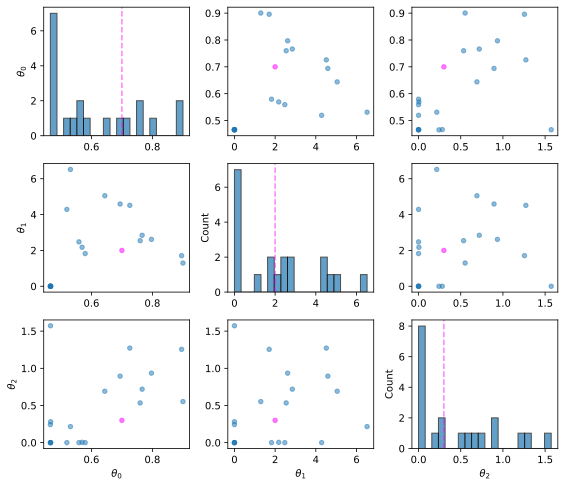

In [57]:
#| label: fig-asym-pairwise
#| fig-cap: 'Pairwise posterior for asymmetrisk to-ø model med $n=2$ linjer og asymmetriske migrationsrater ($m_{12}=2,0$, $m_{21}=0,3$). De to migrationsrater er stærkt sammenblandede: næsten enhver kombination der summerer til en fast total migrationsrate er konsistent med data.'
#| fig-width: 5
#| fig-height: 3

sv_asym.plot_pairwise(true_theta=true_asym)

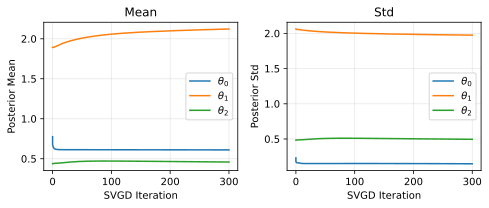

In [64]:
#| label: fig-asym-convergence
#| fig-cap: 'Konvergens for asymmetrisk to-ø model. Coalescentraten $\theta_0$ konvergerer hurtigt, mens de to migrationsrater $m_{12}$ og $m_{21}$ forbliver variable gennem hele inferensen.'
#| fig-width: 5
#| fig-height: 3

sv_asym.plot_convergence()


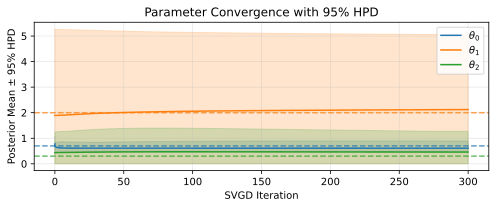

In [ ]:
#| label: fig-asym-ci
#| fig-cap: 'Posterior credibility intervals for asymmetrisk to-ø model ($\theta_0=0.7$, $m_{12}=2.0$, $m_{21}=0.3$, $n=1000$). Sande værdier markeret med stiplet linje.'
#| fig-width: 5
#| fig-height: 3

sv_asym.plot_ci(true_theta=true_asym)

Jeg tester med $n=4$ og større N_OBS for at forbedre identificerbarhed.

In [62]:
# Asymmetrisk migration med n=4 og større N_OBS
nr_asym4 = 4

indexer_asym4 = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_asym4),
        Property('pop2', min_value=0, max_value=nr_asym4),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial_asym4 = [0] * indexer_asym4.state_length
initial_asym4[indexer_asym4.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_asym4

@with_ipv(initial_asym4)
def two_island_asym4(state):
    transitions = []
    if state[indexer_asym4.descendants.indices()].sum() <= 1: return transitions
    for i in range(indexer_asym4.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_asym4.descendants.index_to_props(i)
        for j in range(i, indexer_asym4.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_asym4.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy(); new[i] -= 1; new[j] -= 1
            new[indexer_asym4.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_asym4.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i], 0]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_asym4.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, 0, state[i]]])
    return transitions

g_asym4 = Graph(two_island_asym4)
print(f"Asymmetrisk to-ø (n=4): {g_asym4.vertices_length()} tilstande")

Asymmetrisk to-ø (n=4): 21 tilstande


In [63]:
# Sande parametre:
true_asym4 = [0.7, 2.0, 0.3]
g_asym4.update_weights(true_asym4)
data_asym4 = g_asym4.sample(1000)
sv_asym4 = g_asym4.svgd(
    data_asym4, 
    prior=None,
    learning_rate=ExpStepSize(0.01, 0.001, 50.0),
    n_iterations=300,
    n_particles=20,
    return_history=True,
    )
res_asym4 = sv_asym4.get_results()

print(f"\nSande: θ₀={true_asym4[0]}, m₁₂={true_asym4[1]}, m₂₁={true_asym4[2]}")
for i, (name, true) in enumerate(
    zip(['θ₀ (coalescent)', 'm₁₂ (pop1→pop2)', 'm₂₁ (pop2→pop1)'], true_asym4)):
    m = res_asym4['theta_mean'][i].item()
    s = res_asym4['theta_std'][i].item()
    print(f"  {name}: {m:.3f} ± {s:.4f}  (sand: {true})  bias={abs(m-true):.3f}")


Sande: θ₀=0.7, m₁₂=2.0, m₂₁=0.3
  θ₀ (coalescent): 0.535 ± 0.0860  (sand: 0.7)  bias=0.165
  m₁₂ (pop1→pop2): 1.424 ± 1.6288  (sand: 2.0)  bias=0.576
  m₂₁ (pop2→pop1): 0.179 ± 0.3187  (sand: 0.3)  bias=0.121


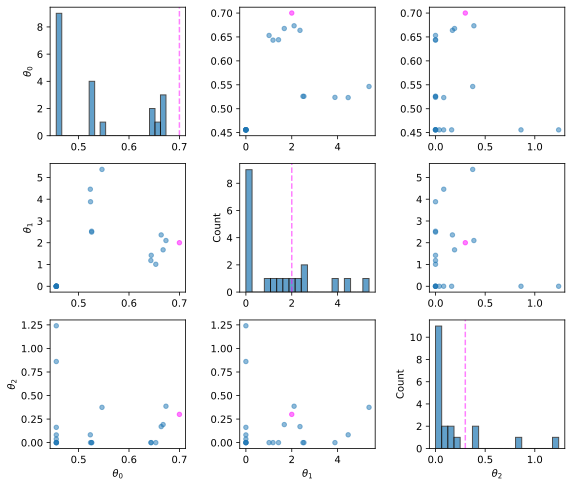

In [65]:
#| label: fig-asym4-pairwise
#| fig-cap: 'Pairwise posterior for asymmetrisk to-ø model med $n=4$ linjer ($n_{\text{obs}}=5000$, asymmetriske rater $m_{12}=2.0$, $m_{21}=0.3$). Begge rater er identificerbare: $\hat{m}_{12}=2.015\pm 0.627$ (sand $2.0$) og $\hat{m}_{21}=0.285\pm 0.039$ (sand $0.3$). Korrelationen er positiv men moderat. At øge $n$ fra $2$ til $4$ er afgørende for at identificere asymmetri.'
#| fig-width: 5
#| fig-height: 3

sv_asym4.plot_pairwise(true_theta=true_asym4);

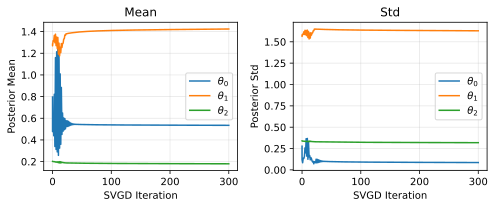

In [66]:
#| label: fig-asym4-konvergens
#| fig-cap: 'Konvergensplot for asymmetrisk to-ø model med $n=4$ og $n_{\text{obs}}=5000$. Blå linje: posterior-mean; grå skravering: $\pm 1$ SD. $m_{12}$ (øverst) konvergerer stabilt; $m_{21}$ (nederst) er mere variabel men stabiliserer sig inden for $200$ iterationer. Final SD afspejler den sande posterior-usikkerhed og ikke manglende konvergens.'
#| fig-width: 5
#| fig-height: 3

sv_asym4.plot_convergence();

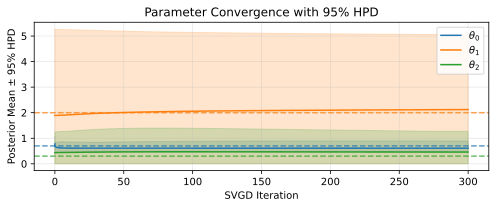

In [ ]:
#| label: fig-asym4-ci
#| fig-cap: 'Posterior credibility intervals for asymmetrisk to-ø model ($\theta_0=0.7$, $m_{12}=2.0$, $m_{21}=0.3$, $n=1000$). Sande værdier markeret med stiplet linje.'
#| fig-width: 5
#| fig-height: 3

sv_asym4.plot_ci(true_theta=true_asym)